# Movie Trailer Analysis

## Load Files and API Keys
In order to run this notebook, collect the appropriate YouTube and IMDb movie IDs. After, click on "Runtime" -> "Run all". First, you will allow access to your Drive, as requested in the first cell. The next two cells will prompt you to paste in the respective IDs; do that!. From there, simply wait for the analysis to load.


Provide the YouTube trailer's video ID to generate a .CSV file of its comments.

In [2]:
from dotenv import load_dotenv
import os

# Load environment variables from .env file
load_dotenv()

True

In [3]:
# How many trailers are you parsing?
while True:
  num_trailers = input("Enter number of trailers to analyze: ")
  try:
    num_trailers = int(num_trailers)
    if num_trailers < 0:
      print('Error: enter a valid positive integer. \n')
      continue
    else:
      break
  except:
    print('Error: enter a valid positive integer. \n')
    continue

In [4]:
# Insert YouTube video ID
trailer_ids = []
for trailer in range(num_trailers):
  video_id = input("Please enter the string for each YouTube ID: ")
  trailer_ids.append(video_id)

In [5]:
# # Do you need to upload any files?
# from google.colab import files

# upload_files = input("Enter 'Yes' if there are additional files to analyze: ")
# upload_files = upload_files.lower()
# # Upload the .csv file
# if upload_files == 'yes':
#   uploaded = files.upload()

#   # Ensure only one file is uploaded & Read the file into a DataFrame
#   for filename in uploaded.keys():
#       temp = pd.read_csv(io.StringIO(uploaded[filename].decode('utf-8')))
#       break  # Only process the first file in case multiple files are uploaded

Insert IMDb Movie ID to discover new insights about user comments in relation to your movie of interest.

In [6]:
# Insert IMDb video ID
movie_id = input("Please enter a string: ")
print(f"You entered: {movie_id}")

You entered: 1160419


In [7]:
# !pip -q install transformers openai==0.27.4 xformers emoji tiktoken IMDbPY langdetect

# File Imports
import os
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from transformers import pipeline
import nltk
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
import emoji
import tiktoken
from imdb import IMDb
import spacy
from langdetect import detect
import nltk
import copy
import httplib2
from googleapiclient.discovery import build_from_document
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor
import time
from openai.error import APIError, OpenAIError, RateLimitError, ServiceUnavailableError, Timeout, TryAgain
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from bs4 import BeautifulSoup
# from google.colab import files
from IPython.display import display, Markdown
import io
import openai
import html
import json
import ast
import concurrent.futures
from concurrent.futures import ThreadPoolExecutor
import requests

nltk.download('stopwords')
pd.options.display.max_colwidth = 100

/opt/homebrew/anaconda3/envs/socialsense/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/guillaumedherouville/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### YouTube Trailer Comments Download


In [8]:
api_key = os.getenv('YOUTUBE')
http = httplib2.Http()
service_name = 'youtube'
version = 'v3'
discovery_url = f'https://www.googleapis.com/discovery/v1/apis/{service_name}/{version}/rest'
discovery_http = http.request(discovery_url)[1]
youtube_service = build_from_document(discovery_http, developerKey=api_key)

In [9]:
def check_api_key(api_key, video_id="dQw4w9WgXcQ"):  # Using a well-known video ID as default
    url = f"https://www.googleapis.com/youtube/v3/videos?id={video_id}&part=snippet&key={api_key}"
    response = requests.get(url)
    if response.status_code == 200:
        print("API Key is valid!")
        # You can print response.json() to see the details
    else:
        print(f"Failed to validate API Key. Status Code: {response.status_code}")
        print(f"Response: {response.json()}")
check_api_key(api_key)

API Key is valid!


In [10]:
def get_video_comments(service, **kwargs):
  comments = []
  results = service.commentThreads().list(**kwargs).execute()

  with tqdm() as progress_bar:  # create a progress bar

      while results:
          for item in results['items']:
              comment = item['snippet']['topLevelComment']['snippet']['textDisplay']
              comments.append(comment)

          progress_bar.update()  # update progress bar

          if 'nextPageToken' in results:
              kwargs['pageToken'] = results['nextPageToken']
              results = service.commentThreads().list(**kwargs).execute()
          else:
              break

  return comments

def write_comments_to_csv(comments, filename):
  df = pd.DataFrame(comments, columns=['comment'])
  return df

In [20]:
if len(trailer_ids) > 0:
  df_list = []
  for idx, video_id in enumerate(trailer_ids):
      comments = get_video_comments(youtube_service, part='snippet', videoId=video_id)
      filename = f'comments_{video_id}.csv'
      df = write_comments_to_csv(comments, filename)
      df_list.append(df)
  temp = pd.concat(df_list)

1063it [03:22,  5.24it/s]


### Remove NaN and non-English Text
This takes a noticeably long amount of time to run. It is probably more useful to leave junk text in each dataframe, as sentiment / entity analysis will not pick up on it anyways.

In [21]:
temp.dropna(inplace = True)

def detect_lang(text):
  try:
      lang = detect(text)
  except:
      lang = 'unknown'
  return lang

# Apply the function to each row in the dataframe
temp['language'] = temp['comment'].apply(detect_lang)

# Filter out rows that are not in English
temp = temp[temp['language'] == 'en']

# Reset Index
temp = temp.reset_index(drop = True)

In [22]:
temp = temp.iloc[:1000]

In [23]:
# Copy DataFrame
temp_org = temp.copy()

# Randomly choose 3,000 comments
# temp = temp.sample(n=3000).reset_index(drop=True)
temp = temp.reset_index(drop=True)

# Printing first_5
print(temp.head(5))

# Another backup for the sampled dataframe
org = copy.deepcopy(temp)

# Store total amount of comments for later
comment_total = len(temp)

                                                                                               comment  \
0                                                                         Me and my wife don’t like it   
1                                                                    This isn&#39;t the trailer tho...   
2                                                         such a mind blowing cinematic masterpiece !!   
3                                          can anyone recommend this movie within an hour? is it good?   
4  <a href="https://www.youtube.com/watch?v=8g18jFHCLXk&amp;t=190">3:10</a> this shot looks very si...   

  language  
0       en  
1       en  
2       en  
3       en  
4       en  


In [24]:
# Extract all comments
comments = temp['comment'].tolist()

In [25]:
# Copy DataFrame
temp_org = temp.copy()

# Randomly choose 3,000 comments (this line is commented out in your code)
# temp = temp.sample(n=3000).reset_index(drop=True)

# Reset index of DataFrame
temp_org = temp_org.reset_index(drop=True)

# Extract all comments
comments_t = temp_org['comment'].tolist()

def remove_emojis_and_apostrophes(text):
    # Convert HTML entities to text
    text = html.unescape(text)
    # Convert emojis to text
    text = emoji.demojize(text)
    # Remove HTML anchor tags and their content
    text = re.sub(r'<a\s+href=.*?>.*?</a>', '', text, flags=re.IGNORECASE)
    # Remove apostrophes and double quotes
    text = text.replace("'", "").replace('"', '')
    text = text.replace('“', '').replace('”', '')
    text = text.replace('‘', '').replace('’', '')
    # Remove line breaks if needed.replace('<i>', '')
    text = text.replace('<br>', '').replace('<b>', '').replace('<i>', '').replace('</i>', '').replace('</b>', '')
    return text

# Remove emojis, apostrophes, and other characters from all comments
comments_t = [remove_emojis_and_apostrophes(comment) for comment in comments_t]

# Update the DataFrame with the cleaned comments
temp_org['comment'] = comments_t

# Sentiment Analysis

In [26]:
classifier_1 = pipeline("sentiment-analysis", model='cardiffnlp/twitter-roberta-base-sentiment-latest',  tokenizer='cardiffnlp/twitter-roberta-base-sentiment-latest', return_all_scores=True)
classifier_2 = pipeline("text-classification", model='bhadresh-savani/distilbert-base-uncased-emotion', return_all_scores=True)
classifier_3 = pipeline("sentiment-analysis", model='cardiffnlp/twitter-roberta-base-sentiment-latest',  tokenizer='cardiffnlp/twitter-roberta-base-sentiment-latest')
tokenizer_kwargs = {'padding':True,'truncation':True,'max_length':500}

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.
/opt/homebrew/anaconda3/envs/socialsense/lib/python3.8/site-packages/transformers/pipelines/text_classification.py:104: UserWarning: `retur

In [27]:
# Define a function to get classifier results for a single comment
def get_classifiers_output(comment):
  a = classifier_1(comment, **tokenizer_kwargs)
  b = classifier_2(comment, **tokenizer_kwargs)
  c = classifier_3(comment, **tokenizer_kwargs)
  return a, b, c

In [28]:
with ThreadPoolExecutor() as executor:
    results = list(tqdm(executor.map(get_classifiers_output, comments), total=len(comments)))

# Process the results
all_scores = []
lda_labels = []
emote = []

for (a, b, c) in results:
    for l in range(3):
        all_scores.append(a[0][l]['score'])
    for m in range(6):
        all_scores.append(b[0][m]['score'])
    lda_labels.append(c[0]['label'])
    emote.append(b[0])

100%|██████████| 1000/1000 [03:10<00:00,  5.24it/s]


In [29]:
# Directly compare
comments_comp = temp[['comment']]
emote_flattened = [{emotion['label']: emotion['score'] for emotion in comment_emotions} for comment_emotions in emote]
emote_df = pd.DataFrame(emote_flattened)
merged_df = pd.concat([comments_comp, emote_df], axis = 1)
merged_df['class'] = merged_df[['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']].idxmax(axis = 1)
merged_df

,comment,sadness,joy,love,anger,fear,surprise,class
0,Me and my wife don’t like it,0.030154,0.007458,0.001991,0.956465,0.003552,0.000379,anger
1,This isn&#39;t the trailer tho...,0.023983,0.071568,0.002089,0.744660,0.154396,0.003304,anger
2,such a mind blowing cinematic masterpiece !!,0.001305,0.986730,0.001163,0.003324,0.001437,0.006040,joy
3,can anyone recommend this movie within an hour? is it good?,0.000652,0.997705,0.000589,0.000536,0.000322,0.000196,joy
4,"<a href=""https://www.youtube.com/watch?v=8g18jFHCLXk&amp;t=190"">3:10</a> this shot looks very si...",0.012239,0.703815,0.006101,0.153006,0.106224,0.018615,joy
...,...,...,...,...,...,...,...,...
995,This Zendaya&#39;s actress is not good for this role. They should of cast a more beautiful girl....,0.000694,0.986687,0.009620,0.000285,0.000334,0.002380,joy
996,(No spoiler) Overrated!! The movie is lame and is too slow to gain momentum. Half of the time I ...,0.000409,0.998380,0.000248,0.000249,0.000247,0.000467,joy
997,I can’t stop watching this trailer! 🙃,0.103180,0.050573,0.002532,0.263648,0.573652,0.006415,fear
998,This movie is completely trash.. it so boring.,0.996850,0.000356,0.000201,0.002241,0.000173,0.000178,sadness


In [30]:
# Set up comparison DataFrame
barbie = {
    'negative' : '24.5%',
    'neutral' : '29.6%',
    'positive' : '45.8%',
    'sadness' : '7.1%',
    'joy' : '53.6%',
    'love' : '1.6%',
    'anger' : '26.6%',
    'fear' : '7.8%',
    'surprise' : '3.3%'
}
guardians = {
    'negative' : '30.8%',
    'neutral' : '28.8%',
    'positive' : '39.4%',
    'sadness' : '14.4%',
    'joy' : '47.0%',
    'love' : '1.4%',
    'anger' : '26.0%',
    'fear' : '9.5%',
    'surprise' : '1.6%'
}
oppenheimer = {
    'negative' : '24.0%',
    'neutral' : '30.2%',
    'positive' : '45.8%',
    'sadness' : '6.8%',
    'joy' : '50.3%',
    'love' : '1.0%',
    'anger' : '31.1%',
    'fear' : '8.5%',
    'surprise' : '2.3%'
}
flash = {
    'negative' : '24.9%',
    'neutral' : '30.3%',
    'positive' : '44.9%',
    'sadness' : '8.9%',
    'joy' : '53.1%',
    'love' : '1.5%',
    'anger' : '26.0%',
    'fear' : '8.3%',
    'surprise' : '2.1%'
}
MI7 = {
    'negative' : '14.8%',
    'neutral' : '29.0%',
    'positive' : '56.2%',
    'sadness' : '7.2%',
    'joy' : '57.0%',
    'love' : '2.1%',
    'anger' : '23.1%',
    'fear' : '8.5%',
    'surprise' : '2.1%'
}
spider = {
    'negative' : '19.6%',
    'neutral' : '28.4%',
    'positive' : '52.0%',
    'sadness' : '6.8%',
    'joy' : '49.4%',
    'love' : '1.9%',
    'anger' : '27.8%',
    'fear' : '11.2%',
    'surprise' : '2.5%'
}

movies = [barbie, guardians, oppenheimer, flash, MI7, spider]

# Entity Analysis

In [31]:
def get_movie_entities(movie_id):
  ia = IMDb()
  movie = ia.get_movie(movie_id)

  data = []
  # Entity Analysis

  def add_entities(entities, entity_type):
      for entity in entities:
          row = {
              'Name': entity['name'],
              'Notes': entity.notes if hasattr(entity, 'notes') else "",
              'Entity Type': entity_type
          }

          if hasattr(entity.currentRole, 'keys') and 'name' in entity.currentRole.keys():
              for k,v in entity.currentRole.items():
                  row[f'currentRole["{k}"]'] = v

          elif len(entity.currentRole) > 1:
              for k,v in entity.currentRole[0].items():
                  row[f'currentRole["{k}"]'] = ' / '.join([str(r[k]) for r in entity.currentRole])

          # Add any other available attributes as columns
          for key, value in entity.items():
              if key not in row:
                  row[key] = value

          data.append(row)

  entity_types = ['cast', 'director', 'writers', 'producer', 'cinematographer', 'composer', 'production companies']

  for entity_type in entity_types:
    # Edit to ensure all information is in the keys
      if entity_type in movie.keys():
          if entity_type == 'production companies':
              for company in movie[entity_type]:
                  row = {
                      'Name': company.get('name', ''),
                      'Notes': company.get('notes', ''),
                      'Entity Type': 'Production Company',
                      'currentRole["long imdb name"]': 'Production Company'
                  }

                  # Add any other available attributes as columns
                  for key, value in company.items():
                      if key not in row:
                          row[key] = value

                  data.append(row)
          else:
              add_entities(movie[entity_type], entity_type.title())

  df = pd.DataFrame(data)
  return df


df = get_movie_entities(movie_id)

entities = (
    df
    [['Name', 'currentRole["long imdb name"]']]
    .fillna('')
    .rename(columns={'currentRole["long imdb name"]': 'Role'})
)

to_summarize = temp['comment'].astype(str).tolist()


In [32]:
# Current Issues with entity extraction
# Not all relevant information is always included in movie's keys
def extract_entities_for_llm(movie_id, df):
  ia = IMDb()
  movie = ia.get_movie(movie_id)
  subject_info = []
  keys = ["title", "plot"]
  for key in keys:
    subject_info.append(key +": " + str(movie.get(key)))

  for ind in df.index:
    if df["Entity Type"][ind] == "Cast":
      entity_type = "Cast Member"
      info = entity_type + ": "  + df["Name"][ind] + ", " + "Role: " + df["long imdb name"][ind]
    else:
      entity_type = df["Entity Type"][ind]
      info = entity_type + ": "  + df["Name"][ind]

    subject_info.append(info)


  return "\n".join(subject_info)

movie_info = extract_entities_for_llm(movie_id, df)
movie_info_str = "".join(movie_info)

In [33]:
# Basic entity match
def find_mentioned_entities(comments, entities):
    nlp = spacy.load("en_core_web_sm")

    mentioned_entities = []
    for comment in tqdm(comments):
        doc = nlp(str(comment).lower())
        mentioned = [int(entity.lower() in doc.text) for entity in entities["Name"]]
        mentioned_entities.append(mentioned)

    mentioned_entities_df = pd.DataFrame(mentioned_entities, columns=entities["Name"])
    return mentioned_entities_df.T.drop_duplicates().T

entity_mentions = find_mentioned_entities(to_summarize, entities)
sorted_values = entity_mentions.sum().sort_values(ascending=False).head(10)

100%|██████████| 1000/1000 [00:09<00:00, 101.05it/s]


In [34]:
nltk.download('vader_lexicon')
# Function to analyze the sentiment of a comment and classify it as positive, neutral, or negative
def analyze_sentiment(comment):
    sid = SentimentIntensityAnalyzer()
    sentiment_scores = sid.polarity_scores(comment)

    # Classify the sentiment based on the compound score
    if sentiment_scores["compound"] >= 0.1:
        sentiment_class = "Positive"
    elif sentiment_scores["compound"] <= -0.1:
        sentiment_class = "Negative"
    else:
        sentiment_class = "Neutral"

    return sentiment_class

sentiments = []
for comment in tqdm(to_summarize):
    sentiment = analyze_sentiment(comment)
    sentiments.append(sentiment)

sentiments_df = pd.DataFrame(sentiments, columns=["Sentiment"])
sorted_values_2 = sentiments_df['Sentiment'].value_counts()

# Construct dataframe for neutral comments analysis
neutral_comments_df = pd.DataFrame()
neutral_comments_df['Comments'] = to_summarize
neutral_comments_df['Sentiment'] = sentiments_df['Sentiment']
neutral_comments_df = neutral_comments_df[neutral_comments_df['Sentiment'] == 'Neutral']
neutral_comments = neutral_comments_df['Comments'].astype(str).tolist()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/guillaumedherouville/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
100%|██████████| 1000/1000 [00:05<00:00, 174.75it/s]


In [35]:
mentions = entity_mentions.loc[:,(entity_mentions.sum(0)>3)].copy()
mentions = mentions.loc[mentions.sum(1)>0,:].copy()

sentiment_mentions = sentiments_df.loc[mentions.index,:].copy()
mentions['sentiment'] = sentiment_mentions

column_order = mentions[[c for c in mentions.columns if c!='sentiment']].sum(0).sort_values(ascending=False).index.tolist()
mentions_total = mentions[[c for c in mentions.columns if c!='sentiment']].sum()

# Calculate the sentiment breakdown for each person
sentiment_breakdown = mentions.groupby("sentiment").sum().transpose()

# Merge the data
data = pd.concat([mentions_total, sentiment_breakdown], axis=1)

# Rename the first column to "Total Mentions"
data = data.rename(columns={0: "Total Mentions"})

data = data.loc[column_order,:]

In [36]:
# Getting first 7 rows from df
df_first_7 = data.head(7)

# Printing df_first_7
print(df_first_7)

                  Total Mentions  Negative  Neutral  Positive
Name                                                         
Zendaya                       18         3        6         9
Hans Zimmer                   11         1        2         8
Denis Villeneuve               9         0        1         8
Jason Momoa                    4         1        0         3


## Sentiment, Entity and Emotion Analysis Visualizations and Comparison


This section creates various visuals for the analysis of YouTube comment section.

In [37]:
# Set up table
# Get the mean sentiment for the entire comment section
overall_sentiment = np.mean(np.array(all_scores).reshape(-1, 9), axis=0).tolist()

overall_sentiment_df = pd.DataFrame(overall_sentiment)
overall_sentiment_df = overall_sentiment_df.transpose()
overall_sentiment_df.columns = ['negative', 'neutral', 'positive', 'sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
overall_sentiment_df = overall_sentiment_df.applymap(lambda x: f"{x*100:.1f}%")

ia = IMDb()
movie = ia.get_movie(movie_id)

new_rows = pd.DataFrame(movies)
titles = [movie.get('title'), 'Barbie', 'Guardians of the Galaxy Vol. 3', 'Oppenheimer', 'The Flash', 'Mission Impossible: Dead Reckoning Part 1', 'Spider-Man: Across the Spiderverse']
overall_sentiment_df = pd.concat([overall_sentiment_df, new_rows], axis = 0).reset_index()
overall_sentiment_df.insert(0, 'Title', titles)

# def style_second_row(s):
#     """
#     Highlight the second row in blue and make the text bold.
#     Args:
#         s: pandas Series (row in DataFrame)
#     Returns:
#         A list of styles for each cell in the row.
#     """
#     # 's.name' refers to the index of the row.
#     # Assuming the second row index is '1' (standard 0-based indexing).
#     if s.name == 0:
#         return ['background-color: blue; font-weight: bold' for _ in s]
#     else:
#         return ['' for _ in s]

# # Apply the style to the DataFrame
# styled_df = overall_sentiment_df.style.hide(['index'], axis = 1).apply(style_second_row, axis=1)

# # To display the styled DataFrame in Jupyter Notebook
# styled_df
overall_sentiment_df

,Title,index,negative,neutral,positive,sadness,joy,love,anger,fear,surprise
0,Dune: Part One,0,18.5%,19.6%,61.9%,9.2%,62.6%,2.7%,15.2%,5.4%,5.0%
1,Barbie,0,24.5%,29.6%,45.8%,7.1%,53.6%,1.6%,26.6%,7.8%,3.3%
2,Guardians of the Galaxy Vol. 3,1,30.8%,28.8%,39.4%,14.4%,47.0%,1.4%,26.0%,9.5%,1.6%
3,Oppenheimer,2,24.0%,30.2%,45.8%,6.8%,50.3%,1.0%,31.1%,8.5%,2.3%
4,The Flash,3,24.9%,30.3%,44.9%,8.9%,53.1%,1.5%,26.0%,8.3%,2.1%
5,Mission Impossible: Dead Reckoning Part 1,4,14.8%,29.0%,56.2%,7.2%,57.0%,2.1%,23.1%,8.5%,2.1%
6,Spider-Man: Across the Spiderverse,5,19.6%,28.4%,52.0%,6.8%,49.4%,1.9%,27.8%,11.2%,2.5%


/var/folders/jm/2zytm77j0ms47q8tymwmv8800000gn/T/ipykernel_86520/1606053060.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sentiment_df[col] = sentiment_df[col].apply(percent_to_float)
/var/folders/jm/2zytm77j0ms47q8tymwmv8800000gn/T/ipykernel_86520/1606053060.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sentiment_df[col] = sentiment_df[col].apply(percent_to_float)
/var/folders/jm/2zytm77j0ms47q8tymwmv8800000gn/T/ipykernel_86520/1606053060.py:12: SettingWithCopyWarning: 
A value is trying to b

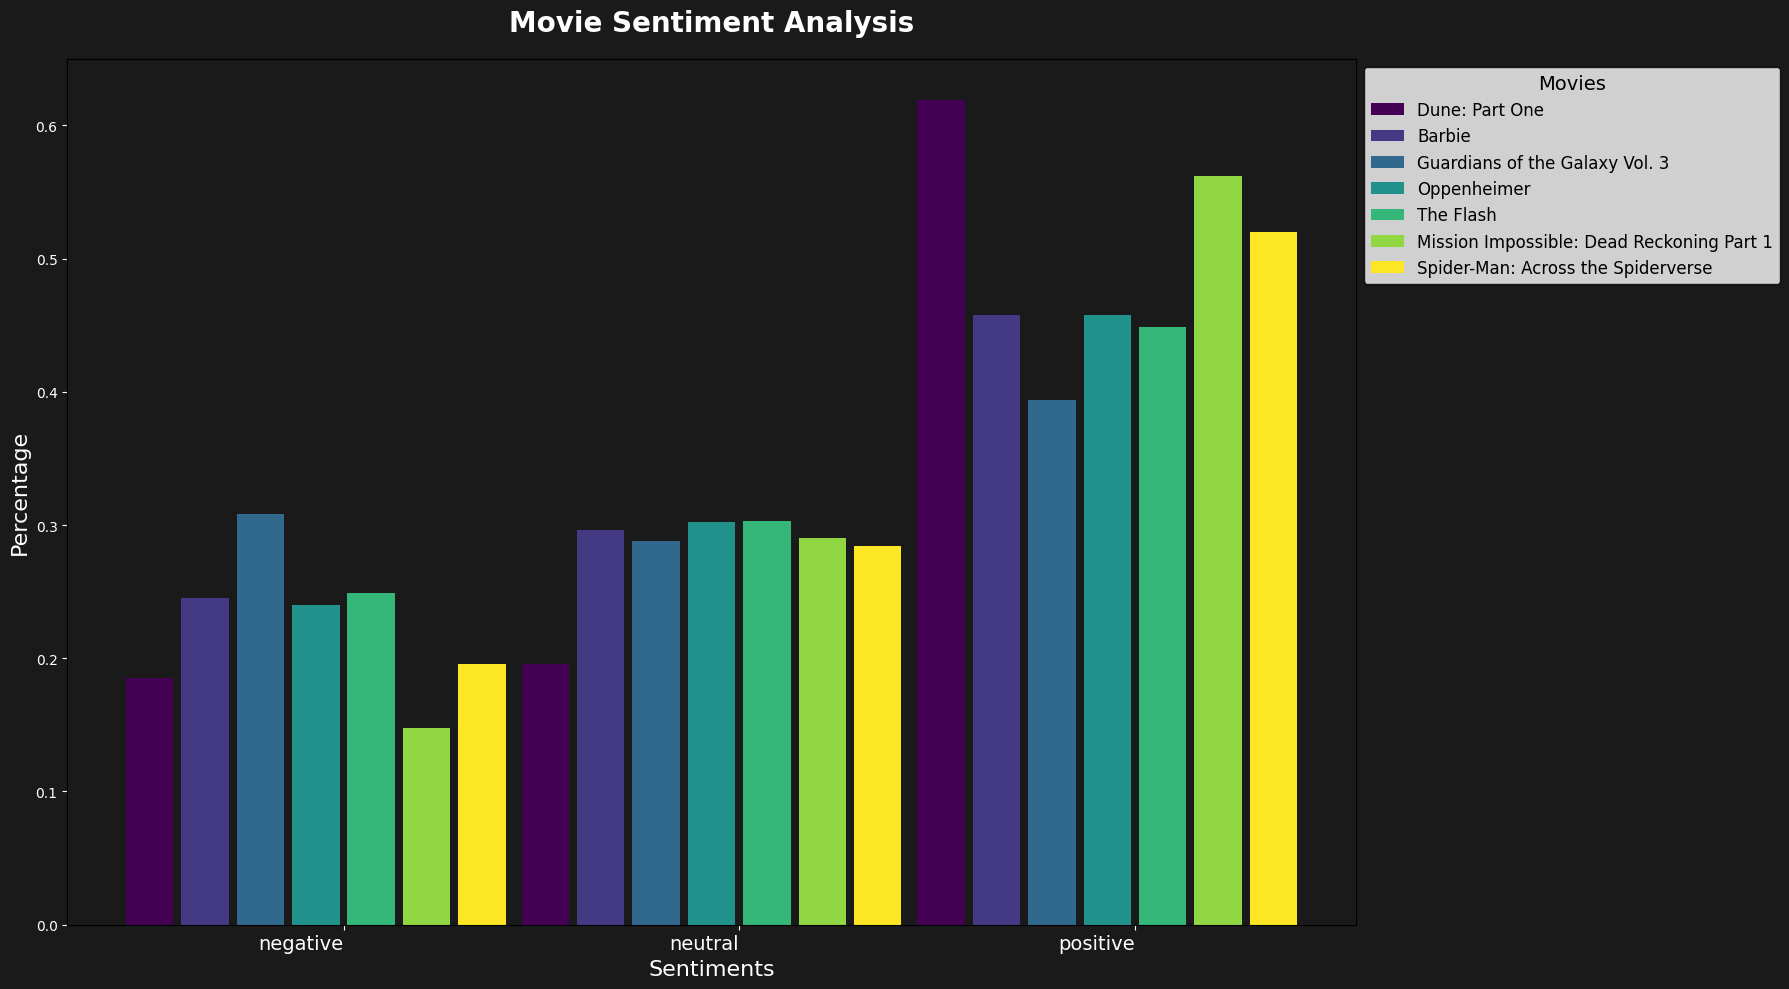

/var/folders/jm/2zytm77j0ms47q8tymwmv8800000gn/T/ipykernel_86520/1606053060.py:63: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emotion_df[col] = emotion_df[col].apply(percent_to_float)
/var/folders/jm/2zytm77j0ms47q8tymwmv8800000gn/T/ipykernel_86520/1606053060.py:63: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emotion_df[col] = emotion_df[col].apply(percent_to_float)
/var/folders/jm/2zytm77j0ms47q8tymwmv8800000gn/T/ipykernel_86520/1606053060.py:63: SettingWithCopyWarning: 
A value is trying to be set on

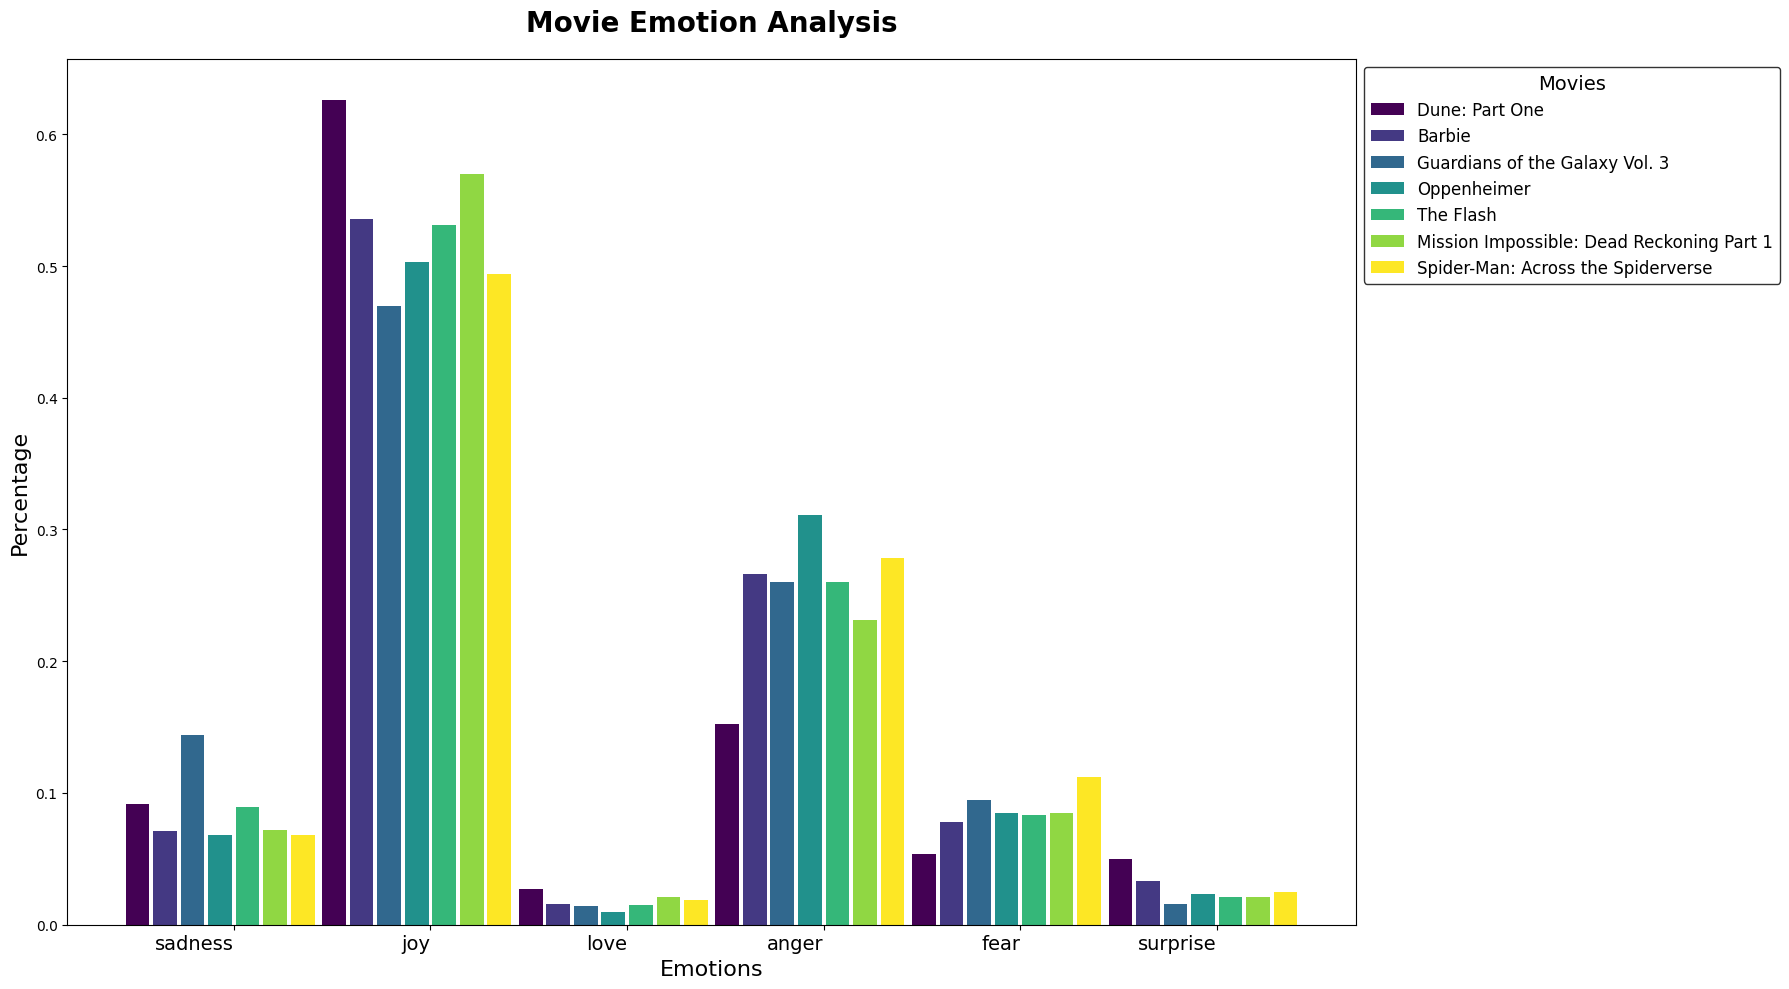

In [38]:
import matplotlib.pyplot as plt

sentiment_df = overall_sentiment_df[['Title', 'negative', 'neutral', 'positive']]
emotion_df = overall_sentiment_df[['Title', 'sadness', 'joy', 'love', 'anger', 'fear', 'surprise']]

# Convert percentages back to float for plotting
def percent_to_float(s):
    return float(s.strip('%'))/100

# Convert the string percentage columns back to floats
for col in sentiment_df.columns[1:]:
    sentiment_df[col] = sentiment_df[col].apply(percent_to_float)

# Set up the figure and axis
fig, ax = plt.subplots(figsize=(18, 10))  # Increase the width to widen the x-axis
plt.gcf().set_facecolor('.1')  # Set the background of the figure
ax.set_facecolor('.1')  # Set the background of the axes

# Number of movies
n_movies = len(sentiment_df['Title'])
width = 0.12  # Adjust width of the bars
spacing = 0.02  # Space between bars

# Generate positions of the bars
positions = list(range(n_movies))

colors = plt.cm.viridis(np.linspace(0, 1, n_movies))

for idx, movie in enumerate(sentiment_df['Title']):
    plt.bar(
        [p + idx * (width + spacing) for p in range(len(sentiment_df.columns[1:]))],
        sentiment_df.loc[idx, sentiment_df.columns[1:]],
        width=width,
        label=movie,
        color=colors[idx]
    )

# Adjust the x-ticks and labels
ax.set_xticks([p + (width + spacing) * n_movies / 2 for p in range(len(sentiment_df.columns[1:]))])
ax.set_xticklabels(sentiment_df.columns[1:], fontsize=14)
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

# Add legend
legend = plt.legend(loc='upper left', bbox_to_anchor=(1,1), ncol=1, fontsize=12)
legend.set_title('Movies', prop={'size': 14})  # Set legend title
legend.get_frame().set_facecolor('white')  # Set legend background color
legend.get_frame().set_edgecolor('black')

# Rotate x labels for better visibility
plt.setp(ax.get_xticklabels(), rotation=0, horizontalalignment='right')

# Enhance the title and labels
ax.set_title('Movie Sentiment Analysis', fontsize=20, fontweight='bold', pad=20, color = "white")
ax.set_xlabel('Sentiments', fontsize=16, color = "white")
ax.set_ylabel('Percentage', fontsize=16, color = "white")

plt.tight_layout()
plt.show()

# Convert the string percentage columns back to floats
for col in emotion_df.columns[1:]:
    emotion_df[col] = emotion_df[col].apply(percent_to_float)

# Set up the figure and axis
fig, ax = plt.subplots(figsize=(18, 10))  # Increase the width to widen the x-axis

# Number of movies
n_movies = len(emotion_df['Title'])
width = 0.12  # Adjust width of the bars
spacing = 0.02  # Space between bars

# Generate positions of the bars
positions = list(range(n_movies))

colors = plt.cm.viridis(np.linspace(0, 1, n_movies))

for idx, movie in enumerate(emotion_df['Title']):
    plt.bar(
        [p + idx * (width + spacing) for p in range(len(emotion_df.columns[1:]))],
        emotion_df.loc[idx, emotion_df.columns[1:]],
        width=width,
        label=movie,
        color=colors[idx]
    )

# Adjust the x-ticks and labels
ax.set_xticks([p + (width + spacing) * n_movies / 2 for p in range(len(emotion_df.columns[1:]))])
ax.set_xticklabels(emotion_df.columns[1:], fontsize=14)

# Add legend
legend = plt.legend(loc='upper left', bbox_to_anchor=(1,1), ncol=1, fontsize=12)
legend.set_title('Movies', prop={'size': 14})  # Set legend title
legend.get_frame().set_facecolor('white')  # Set legend background color
legend.get_frame().set_edgecolor('black')

# Rotate x labels for better visibility
plt.setp(ax.get_xticklabels(), rotation=0, horizontalalignment='right')

# Enhance the title and labels
ax.set_title('Movie Emotion Analysis', fontsize=20, fontweight='bold', pad=20)
ax.set_xlabel('Emotions', fontsize=16)
ax.set_ylabel('Percentage', fontsize=16)

plt.tight_layout()
plt.show()

/var/folders/jm/2zytm77j0ms47q8tymwmv8800000gn/T/ipykernel_86520/1320126070.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_values_2.index, y=sorted_values_2, ax=axes[1], palette=palette, edgecolor='white', order=['Positive', 'Neutral', 'Negative'])


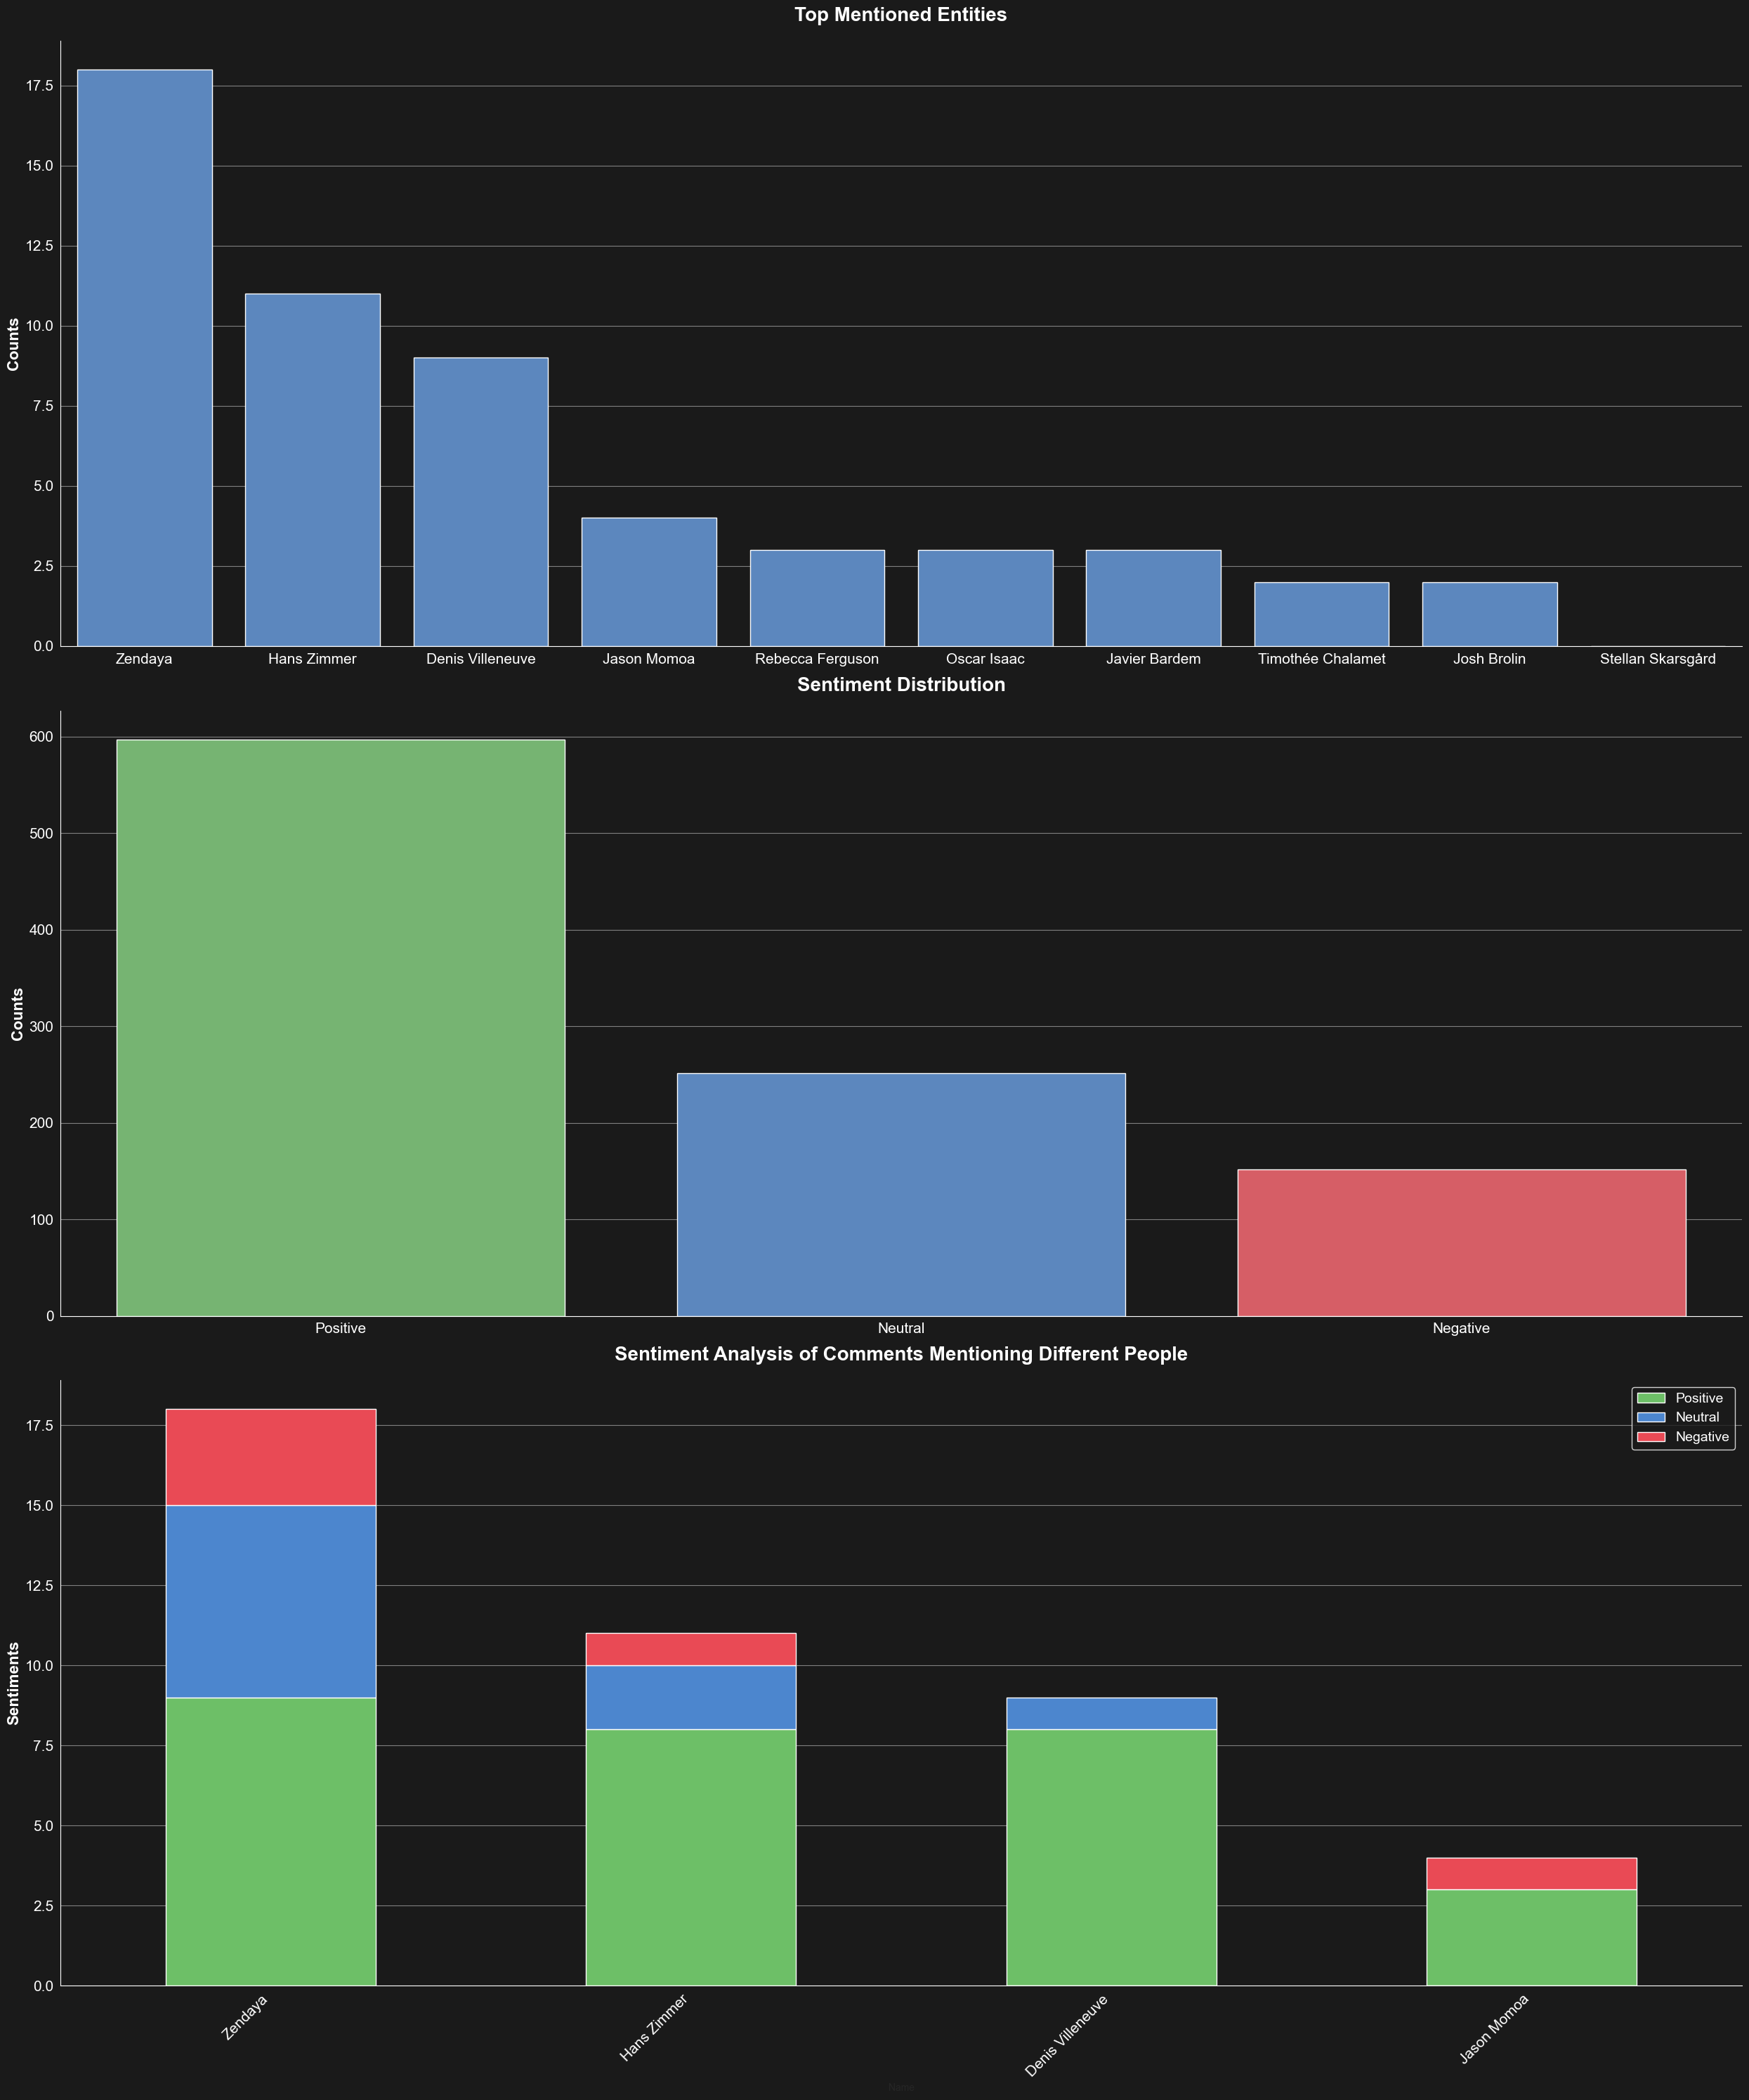

In [39]:
# Set a refined style with no gridlines
sns.set_style("darkgrid", {"axes.grid": False, "axes.facecolor": ".1"})

# Custom color palette: muted green for positive, and two other colors from coolwarm for neutral and negative
muted_green = "#6dbf67"
colors = sns.diverging_palette(250, 10, s=75, l=55, n=2)
coolwarm_blue = colors[0]
coolwarm_red = colors[1]
palette = [muted_green, coolwarm_blue, coolwarm_red]

# Plotting
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(25, 30))

# Set the overall background color of the figure to black
fig.patch.set_facecolor(".1")

# 1st chart: Bar chart for sorted_values
sns.barplot(x=sorted_values.index, y=sorted_values, ax=axes[0], color=coolwarm_blue, edgecolor='white')
axes[0].set_title("Top Mentioned Entities", fontsize=20, fontweight='bold', pad=20, color="white")
axes[0].tick_params(colors='white', which='both', labelsize=15)
axes[0].set_xlabel('')
axes[0].set_ylabel('Counts', fontsize=16, fontweight='bold', color="white")
axes[0].yaxis.grid(True, color="grey")

# 2nd chart: Bar chart for top mentioned entities
# Order and hue_order ensures colors match sentiments correctly
sns.barplot(x=sorted_values_2.index, y=sorted_values_2, ax=axes[1], palette=palette, edgecolor='white', order=['Positive', 'Neutral', 'Negative'])
axes[1].set_title("Sentiment Distribution", fontsize=20, fontweight='bold', pad=20, color="white")
axes[1].tick_params(colors='white', which='both', labelsize=15)
axes[1].set_xlabel('')
axes[1].set_ylabel('Counts', fontsize=16, fontweight='bold', color="white")
axes[1].yaxis.grid(True, color="grey")

# 3rd chart: Sentiment breakdown bar chart
data[['Positive', 'Neutral', 'Negative']].plot(kind='bar', stacked=True, ax=axes[2], color=palette)
axes[2].set_title("Sentiment Analysis of Comments Mentioning Different People", fontsize=20, fontweight='bold', pad=20, color="white")
axes[2].set_ylabel("Sentiments", fontsize=16, fontweight='bold', color="white")
axes[2].tick_params(colors='white', which='both', labelsize=15)
axes[2].legend(facecolor='.1', edgecolor='white', labelcolor='white', fontsize=14, loc='upper right')
axes[2].yaxis.grid(True, color="grey")
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45, ha="right")  # Tilt for x-axis labels

# Remove the right and top spines for a cleaner look
for ax in axes:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

# Display plots
plt.tight_layout()
plt.show()

# Topic Modeling

In [1]:
openai.api_key

NameError: name 'openai' is not defined

In [40]:
# Key
openai.api_key = os.getenv("OPENAI")
key = os.getenv("OPENAI")

In [41]:
# ChatGPT Section
encoding = tiktoken.encoding_for_model("gpt-4o")
def num_tokens_from_string(string: str) -> int:
    """Returns the number of tokens in a text string."""
    num_tokens = len(encoding.encode(string))
    return num_tokens

def chunkify_by_tokens(text, max_tokens):
    words = text.split()
    chunks = []
    chunk = []
    chunk_tokens = 0

    for word in words:
        word_tokens = num_tokens_from_string(word)

        if chunk_tokens + word_tokens <= max_tokens:
            chunk.append(word)
            chunk_tokens += word_tokens
        else:
            chunks.append(' '.join(chunk))
            chunk = [word]
            chunk_tokens = word_tokens

    # Add the last chunk if it's not empty
    if chunk:
        chunks.append(' '.join(chunk))

    return chunks

class ChatGPT:
  def __init__(self, model="gpt-4o", system_message=None):
      self.model = model
      if system_message:
          self.default_system_message = {"role": "system", "content" : system_message}
      else:
          self.default_system_message = {"role": "system", "content" : "Hello! You are the MovieCommentBot. I can answer questions about movies and fans reactions to movies and movie trailers"}
      self.messages = [self.default_system_message]

  def add_system_message(self, message, reset_chat=False):
      if reset_chat:
          self.messages = [self.default_system_message]

      self.messages.append({"role": "system", "content": message})

  def add_user_message(self, message, reset_chat=False):
      if reset_chat:
          self.messages = [self.default_system_message]
      self.messages.append({"role": "user", "content": message})

  def get_response(self):
      response = None
      retries = 0
      while response is None and retries < 6:
          try:
              response = self.send_chat_request()
          except (APIError, OpenAIError, RateLimitError, Timeout) as e:
              print(f"Error: {e}")
              time.sleep(60)  # Wait for 1 minute before retrying
              retries += 1

      if response is None:
          # If all retries failed, escalate the delay time
          time.sleep(2 ** retries)

      return self.process_response(response)

  def send_chat_request(self):
      response = openai.ChatCompletion.create(
          model=self.model,
          messages=self.messages
      )
      return response
  def process_response(self, response):
      # Add the assistant's message to the messages list
      assistant_message = response['choices'][0]['message']['content']
      self.messages.append({"role": "assistant", "content": assistant_message})
      return assistant_message


In [42]:
def TOTAL_SUMMARIZER(texts, token_threshold):
    text = '\n'.join(texts)
    chunks = chunkify_by_tokens(text, token_threshold)
    num_chunks = len(chunks)

    first_pass_summaries = []

    for ci, chunk in enumerate(chunks):
        summarize_prompt = f'Please summarize the following set of comments: \
                            \n\n### COMMENT TEXT\n{chunk}\n\n### BEGIN RESPONSE\n'
        try:
            chat = ChatGPT(system_message="You are an expert text summarizer and analyzer.")
            chat.add_user_message(summarize_prompt)
            summarized_chunk = chat.get_response()
            first_pass_summaries.append(summarized_chunk)

        except Exception as e:
            print(f"Error during initial summarization: {e}")
            # Continue to next chunk instead of returning
            continue

    candidate_text = '\n'.join(first_pass_summaries)
    full_len = num_tokens_from_string(candidate_text)

    iterations = 0
    candidate_len = np.inf

    while candidate_len > token_threshold:
        iterations += 1
        chunks = chunkify_by_tokens(candidate_text, token_threshold)

        summarized_chunks = []
        for chunk in chunks:
            try:
                chat = ChatGPT(system_message="You are an expert text summarizer and analyzer. You are recursively summarizing topics expressed by consumers to select the most commonly expressed topics.")
                summarize_prompt = f"This is a summarization of comments regarding a movie trailer, concerning a movie with this information: \n {movie_info_str} \n. \
                                     List the top 5 most promininent positive aspects of the trailer/film that commenters like and want to see more of.\
                                     List the top 5 most promininent negative aspects of the trailer/film that commenters dislike and/or might cause them to not watch the film.\
                                     Be specific in your generation of topics, and ensure that each topic is distinct. \
                                    \n### TEXT\n{chunk}\n\n### BEGIN RESPONSE\n"
                chat.add_user_message(summarize_prompt)
                summarized_chunk = chat.get_response()
                # Verify and process the summarized chunk here if necessary
                summarized_chunks.append(summarized_chunk)
            except Exception as e:
                print(f"Error during iterative summarization: {e}")
                # Optionally handle the error, like retrying summarization for this chunk
                continue

        candidate_text = ' '.join(summarized_chunks)
        candidate_len = num_tokens_from_string(candidate_text)

    try:
        chat = ChatGPT(system_message="You are an expert text summarizer and analyzer for a production company. Please analyze from the perspective of a producer for this movie. \
                                    You will select the most common topics expressed by consumers regarding a movie trailer.")
        summarize_prompt = f"""This is a summarization of comments regarding a movie trailer, concerning a movie with this information: \n {movie_info_str} \n. \
                            First, list the top 5 most promininent positive aspects of the trailer/film that commenters like and want to see more of.\
                            Next, list the top 5 most promininent negative aspects of the trailer/film that commenters dislike and/or might cause them to not watch the film.\
                            Please place them in a single list separated by by numbers (ex. 1. Theme 1 \n 2. Theme 2 \n etc.) and nothing else \
                            (for example, do not separate into positive and negative groupings. Rather express how they are positive and negative in the themes themseleves) \
                            Also, DO NOT use any apostrophes (') in your response. \
                            In your generation, allow for the topics to be mutually exclusive and collectively exhaustive; each topic should be unique, but all the topics together should comprise the most prominent ideas expressed.\
                            Do not generate more than the 5 positive topics, followed by the 5 negative topics, for a total of 10 topics separeted by one space each. \
                            Here is an example to guide you on how a response should be structured: \
                            1. Positive anticipation for George Millers unique directorial style and passionate fan base hoping to see it continued.
                            2. Thrilled about the increased focus and storyline around Furiosas character and her increased role in future films.
                            3. Great expectations for Anya Taylor-Joy and Chris Hemsworths performances, as well as other major players in the film.
                            4. Excitement for the continuation and expansion of the Mad Max franchise and universe.
                            5. Praise for the trailer's music and visually-appealing components which give a glimpse into the films quality.
                            6. Negative reactions due to the absence of the main character, Mad Max, portrayed by Tom Hardy, causing doubts among viewers.
                            7. Dislike for perceived overreliance on CGI, as viewers believe it takes away from the gritty reality originally established in the series.
                            8. Concerns about perceived forced female empowerment and an overshadowing feminist agenda.
                            9. Doubts about the casting of Anya Taylor-Joy and Chris Hemsworth, with some fans feeling they may not fit the franchises aesthetics.
                            10. Disappointment due to the lack of traditional practical effects and real stunt work, which viewers believe adds authenticity to the series.
                            \n### TEXT\n{candidate_text}\n\n### BEGIN RESPONSE\n"""
        chat.add_user_message(summarize_prompt)
        final_response = chat.get_response()
        # Verify and process the summarized chunk here if necessary
    except Exception as e:
        print(f"Error during iterative summarization: {e}")
        # Optionally handle the error, like retrying summarization for this chunk
        return candidate_text

    return final_response

In [43]:
# Your function to get summarized results
to_summarize_2000 = temp_org['comment'].astype(str).tolist()
all_resp = TOTAL_SUMMARIZER(to_summarize_2000, 3900)
resp_list = all_resp.splitlines()

# Display results
if all_resp:
    display(Markdown('### Summarized Output'))
    display(Markdown('Below is the output from chunking the text and recursively querying OpenAI to summarize the comments:'))
    display(Markdown('Aspects of the trailer/film that commenters like:'))
    display(Markdown('\n'.join(resp_list[0:5])))
    display(Markdown('Aspects of the trailer/film that commenters dislike:'))
    display(Markdown('\n'.join(resp_list[5:10])))
else:
    display(Markdown('**No output received from BASELINE_SUMMARIZER.**'))

### Summarized Output

Below is the output from chunking the text and recursively querying OpenAI to summarize the comments:

Aspects of the trailer/film that commenters like:

1. Stunning visuals and breathtaking cinematography widely praised by the audience. 
2. Timothée Chalamet, Zendaya, and the rest of the cast received high praise for their performances. 
3. Hans Zimmers musical score enhanced the films depth and garnered significant acclaim.
4. Positive reception for the films adherence to Frank Herberts novel, capturing its essence and scope.
5. High anticipation for sequels and the continuation of the story built on a strong storytelling foundation.

Aspects of the trailer/film that commenters dislike:

6. Criticism regarding slow pacing and an overlong introduction, making the film feel too lengthy.
7. Disappointment over Zendayas limited screen time, contrary to trailer expectations.
8. Inconsistent audio quality making dialogue hard to understand and detracting from the viewing experience.
9. Unfavorable comparisons to the 1984 adaptation, with fans finding emotional engagement lacking.
10. Concerns about cultural sensitivity and casting choices, particularly the limited depiction of Middle Eastern talent and the portrayal of cultural elements.

In [44]:
encoding = tiktoken.encoding_for_model("gpt-4")
class ChatGPT:
  def __init__(self, model="gpt-4", system_message=None):
      self.model = model
      if system_message:
          self.default_system_message = {"role": "system", "content" : system_message}
      else:
          self.default_system_message = {"role": "system", "content" : "Hello! You are the MovieCommentBot. I can answer questions about movies and fans reactions to movies and movie trailers"}
      self.messages = [self.default_system_message]

  def add_system_message(self, message, reset_chat=False):
      if reset_chat:
          self.messages = [self.default_system_message]

      self.messages.append({"role": "system", "content": message})

  def add_user_message(self, message, reset_chat=False):
      if reset_chat:
          self.messages = [self.default_system_message]
      self.messages.append({"role": "user", "content": message})

  def get_response(self):
      response = None
      retries = 0
      while response is None and retries < 6:
          try:
              response = self.send_chat_request()
          except (APIError, OpenAIError, RateLimitError, Timeout) as e:
              print(f"Error: {e}")
              time.sleep(60)  # Wait for 1 minute before retrying
              retries += 1

      if response is None:
          # If all retries failed, escalate the delay time
          time.sleep(2 ** retries)

      return self.process_response(response)

  def send_chat_request(self):
      response = openai.ChatCompletion.create(
          model=self.model,
          messages=self.messages
      )
      return response
  def process_response(self, response):
      # Add the assistant's message to the messages list
      assistant_message = response['choices'][0]['message']['content']
      self.messages.append({"role": "assistant", "content": assistant_message})
      return assistant_message


In [45]:
def split_comments(texts, max_tokens):
  chunks = []
  token_count = 0
  past_idx = 0
  for idx, text in enumerate(texts):
    if max_tokens < num_tokens_from_string(text):
      continue
    token_count += num_tokens_from_string(text)
    if token_count > max_tokens:
      chunks.append(texts[past_idx:idx])
      past_idx = idx
      token_count = 0
  return chunks

def generate_summary(text):
  " \n".join(t for t in text)
  topic_analysis_prompt = f"""The following statements represent general expressed themes associated with a set of movie trailer comments \n {all_resp} \n
  You will be given a set of comments concerning the same movie trailer. For each comment, I would like you
  to ouput the original, unedited comment, along with indicators for each comment topic. If the comment relates to the topic,
  you will assign it a 1, otherwise you will assign it a 0. You will output this as a list in JSON format. \n

  For example, consider these topics concerning the trailer for The Social Network:
  1. Overwhelming admiration for the quality of the film and trailer with regards to storytelling, presentation and overall execution. \n
  2. Great appreciation for Director David Finchers directing prowess and his depiction of Facebooks rise, resonating with societal themes. \n
  3. Highly appreciated performances from the cast, with special mentions of actors such as Andrew Garfield and Jesse Eisenberg.
  4. Viewer disapproval of Facebook as a platform and its societal impact, potentially skewing their perception of the film negatively. \n
  5. Criticisms on historical inaccuracy in the portrayal of Facebooks inception and portrayal of Mark Zuckerberg. \n

  And these comments:
  I hate Facebook and I love this movie \n
  I always come back to this movie. Theres nothing like it. Every time I re watch it, theres always something I noice that I didnt the last time. Its art. And the way its created is perfect. \n
  A special movie dedicated to founders of the Facebook and what did went inside their friendship through the process of creating the worlds dominant mass reaching communication forum. Acted perfectly by Andrew and Jesse its a definite watch for audiences across the world. \n
  just rewatched the film last night - even if its not 100% accurate, its a masterpiece of filmmaking, sound design, cinematography. \n
  Lex Luthor created Facebook.
  A lot of people are talking about how great the acting is, but I do not buy it. This movie is carried by the filmmakers behind the camera, even though the story is made-up.
  He's smart, but I don't trust him.


  The output would be:
    {
      {
  0 : "I hate Facebook and I love this movie",
  1 : 1,
  2 : 0,
  3 : 0,
  4 : 1,
  5 : 0
    },
    {
  0 : "I always come back to this movie. Theres nothing like it. Every time I re watch it, theres always something I noice that I didnt the last time. Its art. And the way its created is perfect.",
  1 : 1,
  2 : 0,
  3 : 0,
  4 : 0,
  5 : 0
    },
    {
  0 : "A special movie dedicated to founders of the Facebook and what did went inside their friendship through the process of creating the worlds dominant mass reaching communication forum. Acted perfectly by Andrew and Jesse its a definite watch for audiences across the world.",
  1 : 1,
  2 : 0,
  3 : 1,
  4 : 0,
  5 : 0
    },
    {
  0 : "just rewatched the film last night - even if its not 100% accurate, its a masterpiece of filmmaking, sound design, cinematography.",
  1 : 1,
  2 : 0,
  3 : 0,
  4 : 0,
  5 : 1
    },
    {
  0 : "Lex Luthor created Facebook.",
  1 : 0,
  2 : 0,
  3 : 0,
  4 : 0,
  5 : 0
    },
    {
  0 : "A lot of people are talking about how great the acting is, but I do not buy it. This movie is carried by the filmmakers behind the camera, even though the story is made-up.",
  1 : 1,
  2 : 1,
  3 : 0,
  4 : 0,
  5 : 1

    },
    {
  0 : "He's smart, but I don't trust him.",
  1 : 0,
  2 : 0,
  3 : 0,
  4 : 0,
  5 : 0
    }
    }, where 0 is attributed to the comment, 1 is attributed to the first theme, 2 to the second theme, 3 to the third, etc. Only classify the comment if it directly relates to the respective theme; some comments may not belong to any topic, in which case you will generate 0 for each value of the key-value pairs.

    For example, the comments 'Lex Luthor created Facebook' and 'He's smart, but I don't trust him' are both related to the trailer, but are not specific enough to fit in any category.

    Additionally, although the comment 'A lot of people are talking about how great the acting is, but I do not buy it. This movie is carried by the filmmakers behind the camera, even though the story is made-up.' mentions the praise for the acting, the comment itself is not praiseworth, so it is not attributed to the
    topic 'Highly appreciated performances from the cast, with special mentions of actors such as Andrew Garfield and Jesse Eisenberg'.
.
  Please output in the same format for this comment {text} and the provided themes: {all_resp}. DO NOT output any other text other than the information specified and DO NOT use space brackets '()' or apostrophes like '. Please generate the full comment. It is extremely important that you fully follow these instructions:
  """
  try:
      chat = ChatGPT(system_message="You are an expert comment analyzer who outputs in JSON format. You are not allowed to use any apostrophes (') in your generation. Simply use double quotes("") instead; only use single-quotes ('') inside double-quotes if necessary, never use double-quotes within double-quotes. \
                                     You will be prompted with many comments; please perform the analsys for every single comment, do not skip any even though it may be computationally expensive. \
                                     Please generate the entire comment in your analysis, and only classify the comment if it directly relates to the respective theme, this is extremely important!")
      chat.add_user_message(topic_analysis_prompt)
      summarized_chunk = chat.get_response()

  except Exception as e:
      print(f"Error during initial summarization: {e}")

  return summarized_chunk

def UPDATED_COUNTER_COMMENTS_parallel(texts):
  try:
      with concurrent.futures.ThreadPoolExecutor() as executor:
        comment_jsons = list(executor.map(generate_summary, texts))

  except Exception as e:
      print(f"Error during initial summarization: {e}")
        #return comment_jsons
  return comment_jsons

In [55]:
max_tokens = 200
chunks = split_comments(to_summarize_2000, max_tokens)
# all_jsons = UPDATED_COUNTER_COMMENTS_numbers(chunks, all_resp)
all_jsons = UPDATED_COUNTER_COMMENTS_parallel(chunks[:5])

In [56]:
data_dicts = []
for sample in all_jsons:
    # Correcting the incorrect escape of single quotes and converting HTML entities
    sample = sample.replace("\\'", "'").replace("&#39;", "'")
    try:
        # Try to convert to a dictionary using ast.literal_eval
        data_dict = ast.literal_eval(sample)
    except:
        # If ast.literal_eval fails, try json.loads
        try:
            data_dict = json.loads(sample)
        except:
            continue
    data_dicts.append(data_dict)

In [57]:
# Process the strings into a list of dictionaries
def flatten_concatenation(matrix):
    flat_list = []
    for row in matrix:
      flat_list += row
    return flat_list

flattened_data = flatten_concatenation(data_dicts)
new_data = []
for data in flattened_data:
  new_dict = {}
  idx = 0
  if type(data) == dict:
    for key, value in data.items():
      new_dict[idx] = value
      idx += 1
  else:
    #print("-----")
    #print(data)
    continue
  new_data.append(new_dict)

In [58]:
topic = 10
df = pd.DataFrame(new_data)
for i in range(1, topic + 1):
  print(i)
  new_df = df[df[i] == 1][0]
  new_df = new_df.reset_index()
  for idx, row in new_df.iterrows():
    print(row[0])
  print('--------------------')
  print('\n\n\n\n')

1
such a mind blowing cinematic masterpiece !!
Great beautiful
So far, The greatest of sci-fi movie. İ believe
Most thrilling trailer ever made. This movies is so good..next level :red_heart:
I have never been more impressed by sci-fi movie. Absolutely phenomenal!
Arrakis is so beautiful when the sun is low she literally said that again in dune: part two while kissing with paul under the evening sun. Now I understand why Arrakis is beautiful especially when the sun is low.
My thought while watching this trailer filled with beautiful A list actors and top of the line state of the art effects: how much money did they waste on this film?Edit since reading other comments: My hope is restored. I will be watching this film this year for my annual bday film.
--------------------





2
this shot looks very similar to battle in part two and Zendayas character fighting
I expected far more..Timothee holds the role graciously..for Bardem the role is a too submisove one, the Mother blew me away...

/var/folders/jm/2zytm77j0ms47q8tymwmv8800000gn/T/ipykernel_86520/294049181.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_ones, x='Columns', palette=palette)


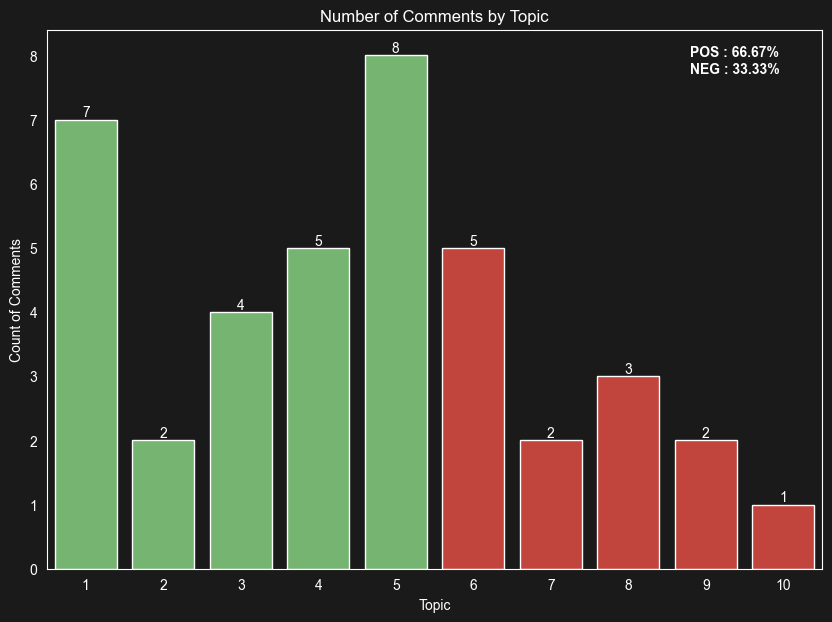

Topics:

1. Stunning visuals and breathtaking cinematography widely praised by the audience. 
2. Timothée Chalamet, Zendaya, and the rest of the cast received high praise for their performances. 
3. Hans Zimmers musical score enhanced the films depth and garnered significant acclaim.
4. Positive reception for the films adherence to Frank Herberts novel, capturing its essence and scope.
5. High anticipation for sequels and the continuation of the story built on a strong storytelling foundation.
6. Criticism regarding slow pacing and an overlong introduction, making the film feel too lengthy.
7. Disappointment over Zendayas limited screen time, contrary to trailer expectations.
8. Inconsistent audio quality making dialogue hard to understand and detracting from the viewing experience.
9. Unfavorable comparisons to the 1984 adaptation, with fans finding emotional engagement lacking.
10. Concerns about cultural sensitivity and casting choices, particularly the limited depiction of Middle Eastern talent and the portrayal of cultural elements.

In [59]:
# Plotting
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 7))

df = pd.DataFrame(new_data)
df_ones = df.drop([0], inplace=False)
df_melted = df.melt(value_vars=df_ones.columns, var_name='Columns', value_name='Count')

# Filter out rows with zeros
df_ones = df_melted[df_melted['Count'] == 1]

# Define your color palette
muted_green = "#6dbf67"
coolwarm_red = "#d73027"
palette = [muted_green] * 5 + [coolwarm_red] * 5  # First 5 bars in muted_green, next 5 in coolwarm_red

# Create the count plot
ax = sns.countplot(data=df_ones, x='Columns', palette=palette)

# Set plot background color
plt.gcf().set_facecolor('.1')  # Set the background of the figure
ax.set_facecolor('.1')  # Set the background of the axes

# Set title and labels with a lighter color for visibility
plt.title('Number of Comments by Topic', color='white')
plt.xlabel('Topic', color='white')
plt.ylabel('Count of Comments', color='white')

# Change the color of the ticks and tick labels
plt.xticks(color='white')
plt.yticks(color='white')

# Change the color of the axes' spines
for spine in ax.spines.values():
    spine.set_edgecolor('white')

# Adding the count above each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='white', xytext=(0, 5),
                textcoords='offset points')

# Calculate total counts for the first 5 and next 5 topics
first_5_total = df_ones[df_ones['Columns'].isin(df_ones['Columns'].unique()[:5])]['Count'].sum()
next_5_total = df_ones[df_ones['Columns'].isin(df_ones['Columns'].unique()[5:])]['Count'].sum()

# Add a rectangle and text for inforaphic
ax = plt.gca()  # Get current axes

positive_perc = first_5_total / (first_5_total + next_5_total) * 100
negative_perc = next_5_total / (first_5_total + next_5_total) * 100
# Infographic text
plt.text(7.8, ax.get_ylim()[1] * 0.92, f'POS : {positive_perc:.4g}%\nNEG : {negative_perc:.4g}%', color='white', fontweight='bold')

plt.show()
# Create the plot
display(Markdown('Topics:'))
display(Markdown(all_resp))

### Marketing Actions

In [73]:
df = pd.read_excel('Marketing Tactics for Trailer Analysis.xlsx', sheet_name='Sheet1')
# sheets = gsheets.worksheet('Sheet1').get_all_values()
# df = pd.DataFrame(gsheets[1:], columns=sheets[0])

tactics = []
for row, value in df.iterrows():
  value_string = "Theme to Address: " + value["Theme to Address"] + "  Marketing Tactic to address this Theme: " + value['Marketing Tactic']
  tactics.append(value_string)

marketing_tactics = '\n \n'.join(tactics)

In [78]:
def generate_summary_marketing(tactics):
  topic_analysis_prompt = f"""
  Here is information on the given film of interest: {movie_info_str}

  Here are the general topics people are discussing related to a certain film: \n {tactics}

  Here is a list of hypothetical themes consumers may be discussing and marketing tactics to address those themes: \n {marketing_tactics}

  Given the topics that users are speaking about your movie trailer, output  10 of the most relevant marketing suggestions you can concoct to help promote the film in list-format, with their reasons for being included in application to this specific film.

  Please use the given list as well as your past knowledge to lend creative and specific suggestions to help market this film.

  Please ensure each suggestion is unique; do not repeat similar suggestions multiple times.
  """
  try:
      chat = ChatGPT(system_message="You are an expert marketing analyzer who outputs marketing advice given topics that users are speaking about.")
      chat.add_user_message(topic_analysis_prompt)
      summarized_chunk = chat.get_response()

  except Exception as e:
      print(f"Error during initial summarization: {e}")

  return summarized_chunk

In [79]:
marketing_actions = generate_summary_marketing(resp_list)
resp_list_mark = marketing_actions.splitlines()

# Display results
if all_resp:
    display(Markdown('### Marketing Actions'))
    display(Markdown('\n'.join(resp_list_mark)))

### Marketing Actions

1. Marketing Suggestion: Organize a Q&A session with the director, Denis Villeneuve, and key cast members from the film.
Reason: Audience discussions show strong admiration for the talents of the director and the cast. Interactive sessions like this will help to engage fans, allowing them to gain further insight into the film and increase their anticipation.

2. Marketing Suggestion: Release a series of short videos or podcasts discussing Hans Zimmer's creation of the film score.
Reason: Discussions identified the film score as a standout aspect of the movie. Showing the process of its creation will intrigue fans and emphasize the hard work and creativity put into the film.

3. Marketing Suggestion: Pre-release articles or behind-the-scenes videos displaying the process and detail put into creating the stunning visuals.
Reason: Audience reaction to the film's breathtaking cinematography is overwhelmingly positive. Displaying the efforts put in to achieve these visuals can heighten appreciation and anticipation for the film.

4. Marketing Suggestion: Address criticism about the film's pacing in a promotional interview, discussing the intention behind it and why it is essential for the film's storytelling.
Reason: Some audience members have criticized the film's pacing. By addressing this directly, you can explain the artistic choice behind it and potentially transform a negative into a Interesting perspective.

5. Marketing Suggestion: Release a series of promotional posters or merchandise featuring the most praised cast members.
Reason: Specific cast members are being talked about positively in discussions, highlighting their acclaim can bolster excitement for their performances.

6. Marketing Suggestion: Host a competition where fans can recreate memorable lines or moments from the movie trailer and share them on social media for a chance to win movie merchandise or premiere tickets.
Reason: This encourages user interaction, increasing engagement and visibility on social media, and can lead to increased awareness and anticipation for the film.

7. Marketing Suggestion: Create a mobile game or interactive experience on popular platforms like Twitch, based on the movie's universe.
Reason: This gives viewers a way to experience the film's world firsthand, further piquing their interest and potentially attracting a new audience from within the gaming community.

8. Marketing Suggestion: Run a campaign emphasizing the film's faithfulness to Frank Herbert's novel.
Reason: Fans of the original material have expressed appreciation for fidelity to the source material, emphasizing this can not only reassure existing fans but could also attract new fans who value adaptation accuracy.

9. Marketing Suggestion: Collaborate with a fashion brand to design a clothing line inspired by the characters' costumes.
Reason: There is a possibility that fans would appreciate the distinct and visually-appealing fashion style in the film, this can bring them closer to the film while increasing exposure within the fashion community.

10. Marketing Suggestion: Release a series of mini-documentaries or articles exploring the real-world social and political themes mirrored in 'Dune'.
Reason: This could provoke thoughtful discussions among fans, potentially introducing new audiences to the film and demonstrating its relevance to current issues, thus increasing its appeal.

## Agentic approach

Considering that graphs / summaries are of good quality, the goal is to improve marketing suggestions 

For now, we want to focus on implementing an agentic approach to the problem, without providing additional marketing data

Let's break it down : we are going to have 3 agents, responsible for action, critique, and judgment
- Action : proposes marketing tactics based on specific comments
- Critique : reviews the tactics and gives feedback to the action agent for improvement
- Judge : evaluates each iteration until the content matches its quality standard